# Информация о данных

* `customerID` - уникальный номер клиента

### Числовые признаки
* `tenure` - сколько месяцев клиент обслуживается
* `MonthlyCharges` - текущий ежемесячный платеж
* `TotalCharges` - суммарно уплачено за все время

### Категориальные признаки
* `gender` (Male/Female) - пол клиента
* `SeniorCitizen` (0/1) - является ли клиент пенсионером
* `Partner` (Yes/No) - есть супруг/партнер
* `Dependents` (Yes/No) - есть дети/другие члены семьи на обеспечении
* `PhoneService` (Yes/No) - подключена ли телефонная связь
* `MultipleLines` (Yes/No/No phone service) - несколько телефонных линий
* `InternetService` (DSL/Fiber optic/No) - тип подключения
* `OnlineSecurity` (Yes/No/No internet service) - антивирус
* `OnlineBackup` (Yes/No/No internet service) - облачное резервное копирование
* `DeviceProtection` (Yes/No/No internet service) - страховка/защита оборудования
* `TechSupport` (Yes/No/No internet service) - приоритетная тех. поддержка
* `StreamingTV` (Yes/No/No internet service) - ТВ через интернет-провайдера
* `StreamingMovies` (Yes/No/No internet service) - стриминг фильмов
* `Contract` (Month-to-month/One year/Two year) - тип подписки на сервис
* `PaperlessBilling` (Yes/No) - электронный счет вместо бумажного
* `PaymentMethod` - способ оплаты

### Целевая переменная
* `Churn` - ушел пользователь или нет

# Исследование данных

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("C:/telco_customer_churn/data/telco_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male
SeniorCitizen,0,0,0,0,0,0,0,0,0,0
Partner,Yes,No,No,No,No,No,No,No,Yes,No
Dependents,No,No,No,No,No,No,Yes,No,No,Yes
tenure,1,34,2,45,2,8,22,10,28,62
PhoneService,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
MultipleLines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
OnlineSecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Категориальные признаки

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df['customerID'].nunique() == df.shape[0]

True

Таким образом, каждый клиент в датасете уникальный и не повторяется

In [9]:
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 
       'Churn', 'PaymentMethod']

for col in cat_features:
    print(df[col].value_counts(normalize=True))
    print("=======")

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64
PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64
MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64
InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64
OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64
OnlineBackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, dtype: float64
DeviceProtection
No                     0.439443
Yes                    0.34388

In [10]:
df[df['InternetService'] == 'No'].T

,11,16,21,22,33,42,58,68,71,73,...,6958,6969,6994,7000,7005,7017,7019,7020,7030,7037
customerID,7469-LKBCI,8191-XWSZG,1680-VDCWW,1066-JKSGK,7310-EGVHZ,9867-JCZSP,3957-SQXML,3170-NMYVV,0731-EBJQB,8028-PNXHQ,...,3078-ZKNTS,4745-LSPLO,0804-YGEQV,0052-YNYOT,9347-AERRL,4807-IZYOZ,9710-NJERN,9837-FWLCH,0871-OPBXW,2569-WGERO
gender,Male,Female,Male,Male,Male,Female,Female,Female,Female,Male,...,Female,Male,Female,Female,Male,Female,Female,Male,Female,Female
SeniorCitizen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Partner,No,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes,...,Yes,No,Yes,No,Yes,No,No,Yes,No,No
Dependents,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,...,Yes,No,Yes,No,No,No,No,Yes,No,No
tenure,16,52,12,1,1,17,34,50,52,62,...,13,1,43,67,23,51,39,12,2,72
PhoneService,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
MultipleLines,No,No,No,No,No,No,Yes,No,No,Yes,...,No,No,Yes,No,No,No,No,No,No,No
InternetService,No,No,No,No,No,No,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No
OnlineSecurity,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,...,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


In [11]:
data_sample = df[df['InternetService'] == 'No']

for col in df.columns:
    if col != 'customerID':
        print(data_sample[col].value_counts(normalize=True))

gender
Male      0.510485
Female    0.489515
Name: proportion, dtype: float64
SeniorCitizen
0    0.965924
1    0.034076
Name: proportion, dtype: float64
Partner
No     0.516383
Yes    0.483617
Name: proportion, dtype: float64
Dependents
No     0.578637
Yes    0.421363
Name: proportion, dtype: float64
tenure
1     0.108781
72    0.043250
2     0.030799
71    0.026868
3     0.025557
        ...   
43    0.005898
49    0.005898
31    0.005898
28    0.005242
0     0.003932
Name: proportion, Length: 73, dtype: float64
PhoneService
Yes    1.0
Name: proportion, dtype: float64
MultipleLines
No     0.775885
Yes    0.224115
Name: proportion, dtype: float64
InternetService
No    1.0
Name: proportion, dtype: float64
OnlineSecurity
No internet service    1.0
Name: proportion, dtype: float64
OnlineBackup
No internet service    1.0
Name: proportion, dtype: float64
DeviceProtection
No internet service    1.0
Name: proportion, dtype: float64
TechSupport
No internet service    1.0
Name: proportion, dtyp

Клиенты, у которых не подключен Интернет, имеют значения `No internet service` во всех признаках с доп. услугами. Поэтому можно заменить это значение на `No`.

In [12]:
cols_to_change = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

map_dict = {
    'No internet service': 'No',
    'No': 'No',
    'Yes': 'Yes'
    }

for col in cols_to_change:
    df[col] = df[col].map(map_dict)

print("Значения изменены:")

for col in cols_to_change:
    print(df[col].value_counts())

Значения изменены:
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


Также заменим значение `No phone service` у признака `MultipleLines`

In [13]:
df['MultipleLines'] = df['MultipleLines'].map({
    'Yes': 'Yes',
    'No': 'No',
    'No phone service': 'No'
})

In [14]:
df['MultipleLines'].value_counts()

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

## Числовые признаки

In [15]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No,No,No,No,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [16]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

### Признак `tenure`

In [17]:
df['tenure'].dtype

dtype('int64')

In [18]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

### Признак `MonthlyCharges`

In [19]:
df['MonthlyCharges'].dtype

dtype('float64')

In [20]:
df['MonthlyCharges'].unique()

array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ], shape=(1585,))

### Признак `TotalCharges`

In [21]:
df['TotalCharges'].dtype

dtype('O')

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [23]:
df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'TotalCharges', 'Churn']]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


Клиенты, которые присоединились в этом месяце, еще не платили, и для них нет данных о том, уйдут они или нет, поэтому необходимо удалить эти данные для дальнейшего анализа

In [24]:
indices_to_drop = df[df['tenure'] == 0].index
df = df.drop(indices_to_drop)

In [25]:
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [26]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [27]:
df[df['TotalCharges'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [28]:
df[num_features].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

### Гистограммы числовых признаков

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

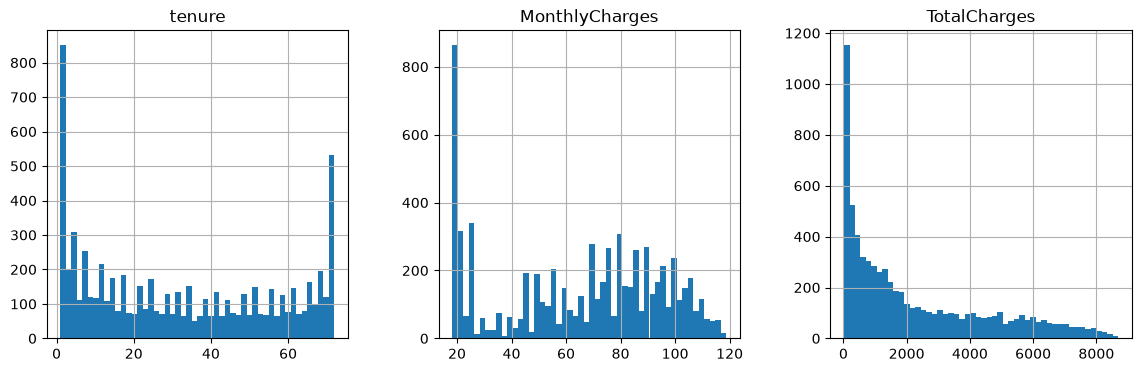

In [29]:
df[num_features].hist(bins=50, figsize=(14, 4), layout=(1, 3))

#### Анализ значений признака `tenure` по краям

<Axes: xlabel='tenure', ylabel='Count'>

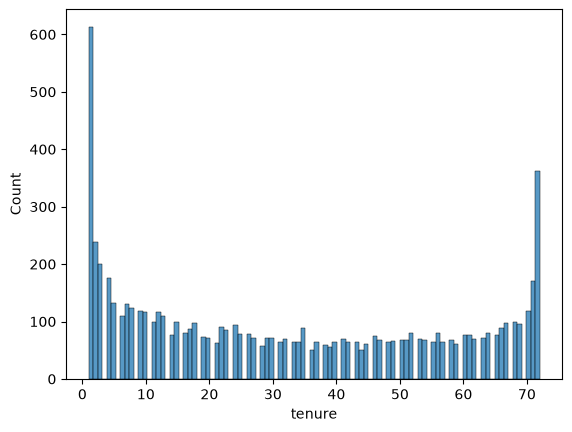

In [30]:
sns.histplot(df['tenure'], bins=100)

<Axes: xlabel='tenure', ylabel='Count'>

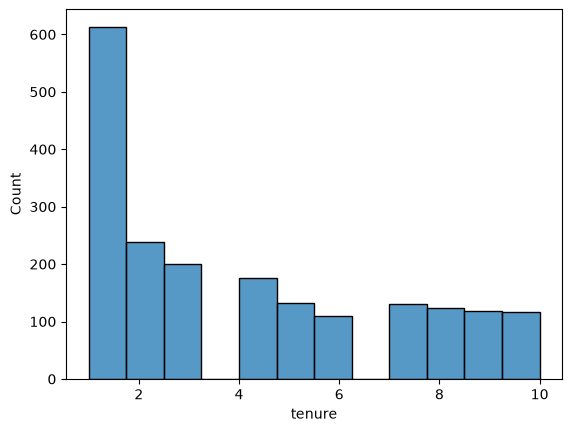

In [31]:
sns.histplot(df[df['tenure'] <= 10]['tenure'])

##### Рассмотрим клиентов с `tenure < 2`

In [32]:
tenure_lt_2 = df[df['tenure'] < 2]

In [33]:
# Среди клиентов с tenure < 2 большинство покинуло сервис в этом месяце
tenure_lt_2['Churn'].value_counts(normalize=True)

Churn
Yes    0.619902
No     0.380098
Name: proportion, dtype: float64

In [34]:
tenure_lt_2.head().T

,0,20,22,27,33
customerID,7590-VHVEG,8779-QRDMV,1066-JKSGK,8665-UTDHZ,7310-EGVHZ
gender,Female,Male,Male,Male,Male
SeniorCitizen,0,1,0,0,0
Partner,Yes,No,No,Yes,No
Dependents,No,No,No,Yes,No
tenure,1,1,1,1,1
PhoneService,No,No,Yes,No,Yes
MultipleLines,No,No,No,No,No
InternetService,DSL,DSL,No,DSL,No
OnlineSecurity,No,No,No,No,No


In [35]:
# почти у всех оформлен месячный тариф
tenure_lt_2['Contract'].value_counts(normalize=True)

Contract
Month-to-month    0.985318
One year          0.011419
Two year          0.003263
Name: proportion, dtype: float64

In [36]:
print("=== Отток клиентов с разными тарифами (tenure < 2) ===")

print("Тип тарифа: каждый месяц")
print(tenure_lt_2[(tenure_lt_2['Contract'] == 'Month-to-month')]['Churn'].value_counts(normalize=True))
print("=======")
print()

print("Тип тарифа: 1 год")
print(tenure_lt_2[(tenure_lt_2['Contract'] == 'One year')]['Churn'].value_counts(normalize=True))
print("=======")
print()

print("Тип тарифа: 2 года")
print(tenure_lt_2[(tenure_lt_2['Contract'] == 'Two year')]['Churn'].value_counts(normalize=True))
print("=======")
print()

=== Отток клиентов с разными тарифами (tenure < 2) ===
Тип тарифа: каждый месяц
Churn
Yes    0.629139
No     0.370861
Name: proportion, dtype: float64

Тип тарифа: 1 год
Churn
No    1.0
Name: proportion, dtype: float64

Тип тарифа: 2 года
Churn
No    1.0
Name: proportion, dtype: float64



Посмотрим на значения других признаков у клиентов, которые перестали пользоваться услугами связи

In [37]:
# tenure_le_2.head().T

data_sample = tenure_lt_2[tenure_lt_2['Churn'] == 'Yes']

for col in data_sample.columns:
    if col != 'customerID':
        print(data_sample[col].value_counts(normalize=True))
        print("======")
        print()

gender
Male      0.510526
Female    0.489474
Name: proportion, dtype: float64

SeniorCitizen
0    0.805263
1    0.194737
Name: proportion, dtype: float64

Partner
No     0.826316
Yes    0.173684
Name: proportion, dtype: float64

Dependents
No     0.847368
Yes    0.152632
Name: proportion, dtype: float64

tenure
1    1.0
Name: proportion, dtype: float64

PhoneService
Yes    0.897368
No     0.102632
Name: proportion, dtype: float64

MultipleLines
No     0.831579
Yes    0.168421
Name: proportion, dtype: float64

InternetService
Fiber optic    0.534211
DSL            0.313158
No             0.152632
Name: proportion, dtype: float64

OnlineSecurity
No     0.952632
Yes    0.047368
Name: proportion, dtype: float64

OnlineBackup
No     0.918421
Yes    0.081579
Name: proportion, dtype: float64

DeviceProtection
No     0.913158
Yes    0.086842
Name: proportion, dtype: float64

TechSupport
No     0.963158
Yes    0.036842
Name: proportion, dtype: float64

StreamingTV
No     0.818421
Yes    0.18157

Можно выдвинуть предположение, что клиенты не попробовали все преимущества сервиса, т.к. у большинства оплачена только телефонная связь без стримингов и доп. услуг

##### Рассмотрим клиентов с `tenure >= 70`

In [38]:
tenure_ge_70 = df[df['tenure'] >= 70]
tenure_ge_70.head(10).T

,17,28,30,35,41,59,62,94,96,106
customerID,9959-WOFKT,5248-YGIJN,3841-NFECX,6234-RAAPL,9489-DEDVP,5954-BDFSG,0526-SXDJP,9848-JQJTX,9803-FTJCG,6728-DKUCO
gender,Male,Male,Female,Female,Female,Female,Male,Male,Male,Female
SeniorCitizen,0,0,1,0,0,0,0,0,0,0
Partner,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes
Dependents,Yes,No,No,Yes,Yes,No,No,No,Yes,Yes
tenure,71,72,71,72,70,72,72,72,71,72
PhoneService,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes
MultipleLines,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes
InternetService,Fiber optic,DSL,Fiber optic,Fiber optic,DSL,Fiber optic,DSL,Fiber optic,DSL,Fiber optic
OnlineSecurity,Yes,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes


In [39]:
print("=== Отток клиентов с разными тарифами (tenure >= 70) ===")

print("Тип тарифа: каждый месяц")
print(tenure_ge_70[(tenure_ge_70['Contract'] == 'Month-to-month')]['Churn'].value_counts(normalize=True))
print("=======")
print()

print("Тип тарифа: 1 год")
print(tenure_ge_70[(tenure_ge_70['Contract'] == 'One year')]['Churn'].value_counts(normalize=True))
print("=======")
print()

print("Тип тарифа: 2 года")
print(tenure_ge_70[(tenure_ge_70['Contract'] == 'Two year')]['Churn'].value_counts(normalize=True))
print("=======")
print()

=== Отток клиентов с разными тарифами (tenure >= 70) ===
Тип тарифа: каждый месяц
Churn
No     0.818182
Yes    0.181818
Name: proportion, dtype: float64

Тип тарифа: 1 год
Churn
No     0.902778
Yes    0.097222
Name: proportion, dtype: float64

Тип тарифа: 2 года
Churn
No     0.975352
Yes    0.024648
Name: proportion, dtype: float64



In [40]:
# tenure_le_2.head().T

data_sample = tenure_ge_70[tenure_ge_70['Churn'] == 'Yes']

for col in data_sample.columns:
    if col != 'customerID':
        print(data_sample[col].value_counts(normalize=True))
        print("======")
        print()

gender
Male      0.608696
Female    0.391304
Name: proportion, dtype: float64

SeniorCitizen
0    0.782609
1    0.217391
Name: proportion, dtype: float64

Partner
Yes    0.826087
No     0.173913
Name: proportion, dtype: float64

Dependents
No     0.695652
Yes    0.304348
Name: proportion, dtype: float64

tenure
70    0.478261
71    0.260870
72    0.260870
Name: proportion, dtype: float64

PhoneService
Yes    0.869565
No     0.130435
Name: proportion, dtype: float64

MultipleLines
Yes    0.826087
No     0.173913
Name: proportion, dtype: float64

InternetService
Fiber optic    0.782609
DSL            0.217391
Name: proportion, dtype: float64

OnlineSecurity
No     0.521739
Yes    0.478261
Name: proportion, dtype: float64

OnlineBackup
Yes    0.782609
No     0.217391
Name: proportion, dtype: float64

DeviceProtection
Yes    0.73913
No     0.26087
Name: proportion, dtype: float64

TechSupport
Yes    0.565217
No     0.434783
Name: proportion, dtype: float64

StreamingTV
Yes    0.913043
No  

Пользователи, которые давно пользуются услугами, имет оплаченные почти все доп. услуги

In [41]:
tenure_ge_70[tenure_ge_70['Contract'] == 'Two year']['Churn'].value_counts(normalize=True)

Churn
No     0.975352
Yes    0.024648
Name: proportion, dtype: float64

#### Проверим гипотезу о том, что **`TotalCharges` = `tenure` * `MonthlyCharges`**

<Axes: ylabel='Count'>

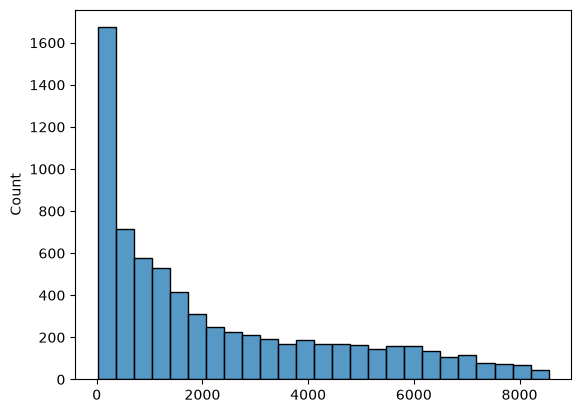

In [42]:
sns.histplot(df['tenure'] * df['MonthlyCharges'])

Графики похожи, проверим корреляцию

In [43]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


Признак `TotalCharges` сильно коррелирует с `tenure`, а также гипотеза о происхождении этого признака подтвердилась, поэтому этот факт надо будет учесть при выборе признаков для модели

# Обработанный датасет

In [44]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No,No,No,No,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


Сохраняем обработанный датасет для дальнейших действий

In [45]:
df.to_csv('clean_data.csv')

In [47]:
for col in df.columns:
    if col != 'customerID':
        print(f"Признак: {col}\nЗначения:{df[col].unique()}")

Признак: gender
Значения:['Female' 'Male']
Признак: SeniorCitizen
Значения:[0 1]
Признак: Partner
Значения:['Yes' 'No']
Признак: Dependents
Значения:['No' 'Yes']
Признак: tenure
Значения:[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
Признак: PhoneService
Значения:['No' 'Yes']
Признак: MultipleLines
Значения:['No' 'Yes']
Признак: InternetService
Значения:['DSL' 'Fiber optic' 'No']
Признак: OnlineSecurity
Значения:['No' 'Yes']
Признак: OnlineBackup
Значения:['Yes' 'No']
Признак: DeviceProtection
Значения:['No' 'Yes']
Признак: TechSupport
Значения:['No' 'Yes']
Признак: StreamingTV
Значения:['No' 'Yes']
Признак: StreamingMovies
Значения:['No' 'Yes']
Признак: Contract
Значения:['Month-to-month' 'One year' 'Two year']
Признак: PaperlessBilling
Значения:['Yes' 'No']
Признак: PaymentMethod
Значения:['Electronic check' 'Mai